<a href="https://colab.research.google.com/github/kirannarayan82/recommendationengine/blob/master/recommendation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [85]:
#Lets generate sample function to generate videoids and video attributes
import random
import string
import pandas as pd
from datetime import datetime
import numpy as np
def randomStringDigits(stringLength=6):
    """Generate a random string of letters and digits """
    lettersAndDigits = string.ascii_letters + string.digits
    return ''.join(random.choice(lettersAndDigits).join(random.choice(lettersAndDigits)) for i in range(stringLength))
print ("Generating a Random String including letters and digits")
print ("First Random String is  ", randomStringDigits(8))

Generating a Random String including letters and digits
First Random String is   zokCorvB


In [86]:
video_count=pd.DataFrame()

In [87]:
videoid=pd.DataFrame(randomStringDigits(8) for _ in range(50000))

In [88]:
noofviews=pd.DataFrame(np.random.randint(20,48,size=50000))

In [89]:
import random
import time
from random import randrange
import datetime
import time
start_timestamp1 = time.mktime(time.strptime('01/06/2017  12:33:00','%d/%m/%Y %H:%M:%S'))
end_timestamp1 = time.mktime(time.strptime('01/03/2020 14:33:00','%d/%m/%Y %H:%M:%S'))
date=pd.DataFrame([time.strftime("%d/%m/%y %H:%M:%S",time.localtime(randrange(start_timestamp1,end_timestamp1))) for _ in range(50000)])
#Generate sample transactionid

<ipython-input-89-05d3e27bd789>:8: DeprecationWarning: non-integer arguments to randrange() have been deprecated since Python 3.10 and will be removed in a subsequent version
  date=pd.DataFrame([time.strftime("%d/%m/%y %H:%M:%S",time.localtime(randrange(start_timestamp1,end_timestamp1))) for _ in range(50000)])


In [90]:
video_count=pd.concat([date,videoid,noofviews],axis=1)

In [91]:
video_count.columns=['date','video_id','count']

In [92]:
#Lets analyse the video count data.
video_count.describe()

,count
count,50000.00000
mean,33.46276
std,8.06979
min,20.00000
25%,26.75000
50%,33.00000
75%,40.00000
max,47.00000


In [93]:
video_count.drop_duplicates()

,date,video_id,count
0,17/08/19 19:27:36,xEUtZ1hJ,25
1,06/01/18 01:46:57,ISfn86UI,30
2,05/10/18 03:23:25,vM0sPwwF,23
3,14/10/17 04:48:26,8QM0M3C0,35
4,02/01/19 09:21:04,5eDvvXyb,30
...,...,...,...
49995,15/05/18 00:52:16,31UZ10L6,31
49996,24/02/20 12:27:38,hrE0i2YK,28
49997,15/12/17 03:04:22,QcizpbIj,30
49998,17/01/18 02:41:15,LHohi7wL,24


In [94]:
#check the datatypes of the dataframe
video_count.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   date      50000 non-null  object
 1   video_id  50000 non-null  object
 2   count     50000 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.1+ MB


In [95]:
# Need to convert the date column to a datetime object
video_count['date']=pd.to_datetime(video_count['date'])

<ipython-input-95-5a9be5543c17>:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  video_count['date']=pd.to_datetime(video_count['date'])


In [96]:
#check for any missing values
video_count.isnull().sum()
#No missing values in the data

,0
date,0
video_id,0
count,0


In [97]:

videoquality=['180p','720p']
video_quality=pd.DataFrame([np.random.choice(videoquality) for _ in range(50000)])


In [98]:
videolanguage=['En','Cn']
video_language=pd.DataFrame([np.random.choice(videolanguage) for _ in range(50000)])

In [99]:
videouploaddate=pd.DataFrame([time.strftime("%d/%m/%y %H:%M:%S",time.localtime(randrange(start_timestamp1,end_timestamp1))) for _ in range(50000)])
#Generate sample transactionid

<ipython-input-99-182c1b2e2ffe>:1: DeprecationWarning: non-integer arguments to randrange() have been deprecated since Python 3.10 and will be removed in a subsequent version
  videouploaddate=pd.DataFrame([time.strftime("%d/%m/%y %H:%M:%S",time.localtime(randrange(start_timestamp1,end_timestamp1))) for _ in range(50000)])


In [100]:
videolength=pd.DataFrame(np.random.randint(120,180,size=50000))

In [101]:
video_features=pd.concat([video_quality,video_language,videouploaddate,videolength],axis=1)

In [102]:
video_features=pd.concat([video_features,videoid],axis=1)

In [103]:
video_features.columns=['video_quality','video_language','video_upload_date', 'video_length','video_id']

In [104]:
#merge videocount and video features
mergeddata=pd.merge(video_count,video_features,on='video_id')

In [105]:
mergeddata.columns

Index(['date', 'video_id', 'count', 'video_quality', 'video_language',
       'video_upload_date', 'video_length'],
      dtype='object')

In [106]:
mergeddata

,date,video_id,count,video_quality,video_language,video_upload_date,video_length
0,2019-08-17 19:27:36,xEUtZ1hJ,25,180p,Cn,11/11/19 09:35:28,161
1,2018-06-01 01:46:57,ISfn86UI,30,180p,Cn,21/07/19 04:50:08,156
2,2018-05-10 03:23:25,vM0sPwwF,23,180p,En,10/03/19 13:27:53,168
3,2017-10-14 04:48:26,8QM0M3C0,35,180p,Cn,11/08/19 14:11:23,140
4,2019-02-01 09:21:04,5eDvvXyb,30,180p,Cn,07/09/19 05:11:19,125
...,...,...,...,...,...,...,...
49995,2018-05-15 00:52:16,31UZ10L6,31,180p,Cn,26/02/20 18:46:40,152
49996,2020-02-24 12:27:38,hrE0i2YK,28,180p,Cn,16/02/18 04:43:49,127
49997,2017-12-15 03:04:22,QcizpbIj,30,180p,Cn,18/07/18 14:43:06,166
49998,2018-01-17 02:41:15,LHohi7wL,24,180p,Cn,12/02/18 17:06:17,142


In [107]:
#calculate the mininum number of counts  We will ignore counts which are less than 10 percentile
m=mergeddata['count'].quantile(0.9)


In [108]:
m

np.float64(45.0)

In [109]:
# so as a first filter,We will ignore counts which are less than 1 percentile,thereby we will defibe the hot videos and stable videos are the ones whoch have counts greater than m and views greater than v.So lets isolate the videos whoch are neither hot nor stable
othervideos=mergeddata[(mergeddata['count']<m)]

In [110]:
#For our analysis of hot videos and stable videos we will use only those whose counts are greater than 1 percentile
mergeddata=mergeddata[(mergeddata['count']>m)]


In [111]:
mergeddata

,date,video_id,count,video_quality,video_language,video_upload_date,video_length
8,2020-01-25 09:03:26,B6U4Iv0z,46,720p,En,16/01/18 15:18:47,147
20,2017-08-17 00:12:26,g4NxYzt4,46,180p,Cn,23/02/18 14:26:02,155
53,2017-08-23 18:57:07,BDf3UsWo,46,180p,En,22/08/18 01:48:48,122
75,2019-07-23 09:41:09,Z7H51wjk,46,180p,En,18/07/17 18:05:13,172
101,2018-11-18 11:29:40,3XBJFSB6,46,720p,Cn,01/02/18 21:59:33,174
...,...,...,...,...,...,...,...
49974,2019-08-10 21:00:40,xemhbQbL,46,720p,Cn,10/09/18 23:39:49,122
49981,2017-01-08 21:52:46,fkgwBLky,47,720p,Cn,22/01/18 21:32:07,130
49987,2019-10-03 01:28:05,PXOO5AP1,46,720p,En,18/09/18 11:27:47,156
49993,2018-08-03 17:40:12,1j60kYzO,47,180p,Cn,13/05/19 11:46:36,165


#We Will need some metrics to do our classification and recommendations

In [112]:
#Get the total views for each video
import numpy as np
views=mergeddata.groupby("video_id")["count"].sum().reset_index()


In [113]:
views

,video_id,count
0,00XAcYAM,46
1,01ssgH2Y,46
2,02QUCiLS,47
3,02qiy6tT,46
4,03S6qJSR,47
...,...,...
3548,zuNe1Rag,46
3549,zw3JjCWM,47
3550,zwxtFJvv,47
3551,zy1leqmR,47


In [114]:
#Get the average length for each video
import numpy as np
length=mergeddata.groupby("video_id")["video_length"].median().reset_index()
length

,video_id,video_length
0,00XAcYAM,147.0
1,01ssgH2Y,141.0
2,02QUCiLS,151.0
3,02qiy6tT,169.0
4,03S6qJSR,176.0
...,...,...
3548,zuNe1Rag,129.0
3549,zw3JjCWM,169.0
3550,zwxtFJvv,128.0
3551,zy1leqmR,162.0


In [115]:
#Merging the metrics into a single dataset
summarydata=pd.merge(views,length,on='video_id')

In [116]:
summarydata.columns=['video_id','totalviews','averagelength']

In [117]:
video_count

,date,video_id,count
0,2019-08-17 19:27:36,xEUtZ1hJ,25
1,2018-06-01 01:46:57,ISfn86UI,30
2,2018-05-10 03:23:25,vM0sPwwF,23
3,2017-10-14 04:48:26,8QM0M3C0,35
4,2019-02-01 09:21:04,5eDvvXyb,30
...,...,...,...
49995,2018-05-15 00:52:16,31UZ10L6,31
49996,2020-02-24 12:27:38,hrE0i2YK,28
49997,2017-12-15 03:04:22,QcizpbIj,30
49998,2018-01-17 02:41:15,LHohi7wL,24


In [118]:
summarydata

,video_id,totalviews,averagelength
0,00XAcYAM,46,147.0
1,01ssgH2Y,46,141.0
2,02QUCiLS,47,151.0
3,02qiy6tT,46,169.0
4,03S6qJSR,47,176.0
...,...,...,...
3548,zuNe1Rag,46,129.0
3549,zw3JjCWM,47,169.0
3550,zwxtFJvv,47,128.0
3551,zy1leqmR,47,162.0


 We will define a metric called popularity index. We will define a video as popular if people tend to watch longer than others in other words popular video will be watched for a longer duration and  will have higher views .Combing the duration of video watched as well the count of people who watched the video, we will define popularity index as the Average length of the video multiplied by the total views it has got

popularity index of a given video=Average length of the video*total views for the video

In [119]:
def popindex(dataframe):
    return(dataframe['averagelength']*dataframe['totalviews'])

In [120]:
summarydata['popindex']=summarydata.apply(lambda x:popindex(x),axis=1)
summarydata['popindex']

,popindex
0,6762.0
1,6486.0
2,7097.0
3,7774.0
4,8272.0
...,...
3548,5934.0
3549,7943.0
3550,6016.0
3551,7614.0


In [121]:
#Normalizing the popularity index for easier interpretation
from statistics import mean
from statistics import stdev
summarydata['popindex']=(summarydata['popindex']-mean(summarydata['popindex']))/(stdev(summarydata['popindex']))

we will use the popularity index to build a recommendation engine and also a classification

#Using the KPI popularity index as a means to classify our videos ,we will classify the video which have a popularity index greater than 1 to be "hot videos". This will account for the fact that videos which have high viewership count also high viewership length have generated high level of interest among users

In [122]:
summarydata['video_classify']=np.where(summarydata['popindex']>1,"Hot","Stable")

In [123]:
#Lets try to understand somemore features of the videos
finaldata=pd.merge(summarydata,video_features,on='video_id')

In [124]:
# The average video length and the video length column for each video id is same .so we can drop the average video length can be dropped
finaldata=finaldata.drop(['averagelength'],axis=1)


In [125]:
finaldata.groupby(["video_classify"])["totalviews"].describe().reset_index()

,video_classify,count,mean,std,min,25%,50%,75%,max
0,Hot,750.0,46.593333,0.491539,46.0,46.0,47.0,47.0,47.0
1,Stable,2803.0,46.467356,0.499022,46.0,46.0,46.0,47.0,47.0


In [126]:
finaldata.groupby(["video_classify"])["video_length"].describe().reset_index()

,video_classify,count,mean,std,min,25%,50%,75%,max
0,Hot,750.0,173.417333,3.632735,166.0,171.0,174.0,176.0,179.0
1,Stable,2803.0,143.738851,13.896076,120.0,132.0,144.0,156.0,169.0


In [127]:
# We will need some plots to understand the features of videos classified as hot videos and stable videos
import seaborn as sns
sns.set_context('notebook')
sns.boxplot(finaldata['video_classify'],finaldata['totalviews'])
sns.boxplot(finaldata['video_classify'],finaldata['totalviews'])


TypeError: boxplot() takes from 0 to 1 positional arguments but 2 were given

In [ ]:
lm1=sns.boxplot(finaldata['video_classify'],finaldata['video_length'])



In [128]:
#sns.boxplot(finaldata['video_classify'],finaldata['counts'])
finaldata.columns

Index(['video_id', 'totalviews', 'popindex', 'video_classify', 'video_quality',
       'video_language', 'video_upload_date', 'video_length'],
      dtype='object')

<Axes: xlabel='video_classify', ylabel='count'>

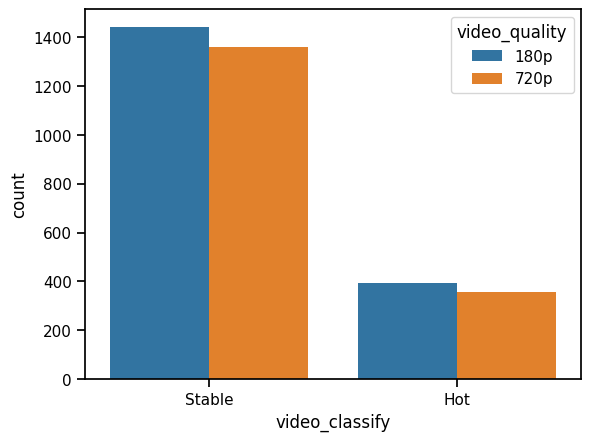

In [129]:
sns.countplot(x="video_classify",hue="video_quality" ,data=finaldata)


<Axes: xlabel='video_classify', ylabel='count'>

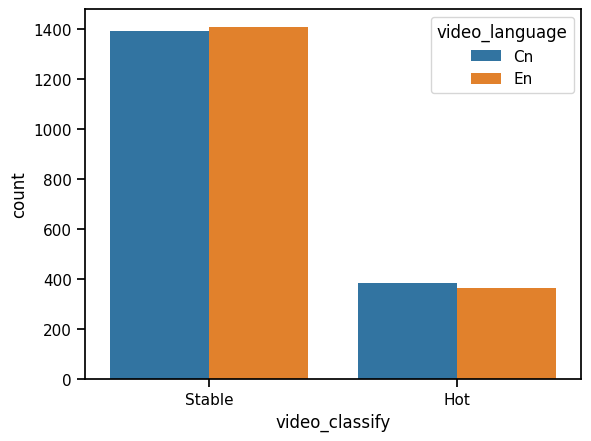

In [130]:
sns.countplot(x="video_classify",hue="video_language" ,data=finaldata)

In [131]:
#Now that we have classified hot videos and stable videos we need to build a recommendation engine using the popularity index defined above

In [132]:
#Pivot the data and generate a sparse matrix to identify similarity between videos usingkneighbors
summarydata_pivot=summarydata.pivot(columns='video_id',values='popindex').fillna(0)

In [133]:
from scipy.sparse import *
from scipy import *

In [134]:
summarydatamatrix=csr_matrix(summarydata_pivot.values)

In [135]:
summarydatamatrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3553 stored elements and shape (3553, 3553)>

In [136]:
from sklearn.neighbors import NearestNeighbors

In [137]:
# We will define k neighbors to identify similar videos based on cosine similarities
model_knn=NearestNeighbors(metric='cosine',algorithm='brute')

In [138]:
model_knn.fit(summarydatamatrix)

NearestNeighbors(algorithm='brute', metric='cosine')

In [139]:
#Lets showcase a sample recommender for any videoid of our choice
choice=np.random.choice(summarydata_pivot.shape[0])

In [140]:
distances,indices=model_knn.kneighbors(summarydata_pivot.iloc[choice,:].values.reshape(1,-1),n_neighbors=5)

In [141]:
indices

array([[1006, 3551, 3550, 3549, 3548]])

In [142]:
distances

array([[0., 1., 1., 1., 1.]])

In [143]:
distances=distances.flatten()



In [144]:
# Here we showcase recommendation for video id 8
for i in range(len(distances)-1):
    print("Recomendation no {0} for video_id {1} is video_id {2}".format(i+1,choice,summarydata_pivot.index[indices.flatten()[i+1]]))

Recomendation no 1 for video_id 1006 is video_id 3551
Recomendation no 2 for video_id 1006 is video_id 3550
Recomendation no 3 for video_id 1006 is video_id 3549
Recomendation no 4 for video_id 1006 is video_id 3548


We have built a simple recommendation engine based on its popularity index as shown above

In [145]:
# prompt: create sample youtube reviews and combine that data with viewership data. generate recommendations based on gpt models

import pandas as pd
# Sample reviews (text data)
reviews = {
    'video_id': ['video_id_1', 'video_id_2', 'video_id_3', 'video_id_4', 'video_id_5'],
    'review_text': [
        'This video was great! Very informative.',
        'Not impressed, the audio quality was poor.',
        'Loved the content, very engaging.',
        'Could be better, a bit too long.',
        'Fantastic video, learned a lot!'
    ]
}
reviews_df = pd.DataFrame(reviews)

# Combine viewership data with sample reviews
combined_data = pd.merge(finaldata, reviews_df, on='video_id', how='left')

# Install necessary libraries for GPT models (e.g., transformers, openai)
!pip install transformers torch

# Note: For real-world GPT model usage, you would need API access or a local setup.
# This is a placeholder demonstrating the concept of integrating text data for recommendations.

# Example using a simple sentiment analysis (as a proxy for GPT-based text analysis)
from transformers import pipeline

sentiment_analyzer = pipeline("sentiment-analysis")

# Apply sentiment analysis to the review text
combined_data['sentiment'] = combined_data['review_text'].apply(
    lambda x: sentiment_analyzer(x)[0]['label'] if pd.notna(x) else None
)

# Basic recommendation logic based on sentiment and existing popularity index
# This is a simplistic example; a real GPT-based recommendation would be more sophisticated
def recommend_based_on_sentiment_and_popularity(df, video_id, n_recommendations=3):
    target_video = df[df['video_id'] == video_id]
    if target_video.empty:
        return "Video ID not found."

    target_sentiment = target_video['sentiment'].iloc[0]
    target_popindex = target_video['popindex'].iloc[0]

    # Filter videos with similar sentiment (if available)
    similar_sentiment_videos = df[df['sentiment'] == target_sentiment].copy()

    # If no videos with the same sentiment, consider all videos (excluding the target)
    if similar_sentiment_videos.empty or similar_sentiment_videos.shape[0] <= 1:
         recommendations = df[df['video_id'] != video_id].copy()
    else:
         recommendations = similar_sentiment_videos[similar_sentiment_videos['video_id'] != video_id].copy()


    # Sort recommendations by popularity index (or a more complex GPT-driven similarity metric)
    recommendations = recommendations.sort_values(by='popindex', ascending=False)

    return recommendations[['video_id', 'sentiment', 'popindex']].head(n_recommendations)

# Example usage of the recommendation function
# Replace 'video_id_1' with a video_id present in your combined_data after the merge
# Note: Since sample reviews were only created for a few IDs, you might get no reviews for other IDs.
print("\nRecommendations for video_id_1:")
print(recommend_based_on_sentiment_and_popularity(combined_data, 'video_id_1'))

# To use GPT for more sophisticated recommendations, you would:
# 1. Generate embeddings for review texts and possibly video features using GPT or other NLP models.
# 2. Use these embeddings to calculate similarity between videos.
# 3. Combine similarity scores with popularity index or other metrics for final recommendations.

# Example (conceptual) of generating embeddings using a transformers model
# from transformers import AutoModel, AutoTokenizer
# tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
# model = AutoModel.from_pretrained("bert-base-uncased")

# def get_embedding(text):
#     if pd.isna(text):
#         return None
#     inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512)
#     outputs = model(**inputs)
#     return outputs.last_hidden_state.mean(dim=1).squeeze().detach().numpy() # Get mean pooling

# combined_data['review_embedding'] = combined_data['review_text'].apply(get_embedding)

# You would then use these embeddings (and potentially embeddings from video features)
# to compute similarity (e.g., cosine similarity) for recommendations.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 111.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 36.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cpu



Recommendations for video_id_1:
Video ID not found.
